In [1]:
from pathlib import Path
from itertools import groupby
import h5py
import numpy as np
import numpy.typing as npt
from numpy.lib.stride_tricks import sliding_window_view
import matplotlib.pyplot as plt
from src.module.utils import load_config
from src.module.labelling import Hypophet, HypophetVersion2

In [2]:
def set_environment(config):
    src_path = Path(config["data_path"]).expanduser() / "02_04.processed"
    save_path = Path(config["data_path"]).expanduser() / "02_04.processed"
    file_path = sorted(src_path.rglob(f"*{config['fs']}fs*processed.h5"))
    env = {"src_path": src_path, "save_path": save_path, "file_path": file_path}
    return env


def load_h5(file_path) -> tuple:
    with h5py.File(file_path, "r") as f:
        ts = f["signal/ts"][:]
        sig = f["signal/abp"][:]
        mbp = f["signal/mbp"][:]
        sqi = f["signal/sqi"][:]
        fs = f["signal"].attrs["fs"]
        sig_len = f["signal"].attrs["len"]
        cid = f.attrs["caseid"]

    return cid, fs, sig_len, ts, sig, mbp, sqi

In [3]:
config = load_config("../../config/conf.yaml")
env = set_environment(config)
print("Hypophetversion2 strategy selected")
strategy = HypophetVersion2()

Hypophetversion2 strategy selected


In [4]:
input_len = config["input_len"]
pred_len = config["pred_len"]
grp = config["event_condition"]["pos"]["group_range"]
adj = config["event_condition"]["neg"]["adjacency"]

In [5]:
file_path = env["file_path"][-15]
print(file_path)

/Users/chishinhwang/Github/SNU-Hypo10Pred_v2/data/02_04.processed/6363/6363_100fs_processed.h5


In [6]:
cid, _, _, _, sig, mbp, sqi = load_h5(file_path)
case_path = Path(config["data_path"]).expanduser() / "02_04.processed" / cid
fname = file_path.name.split(".")[0]
pos_name = (
    f"{fname}_in{input_len}out{pred_len}_grp{grp}_hypophetversion2_pos_events.npy"
)
neg_name = (
    f"{fname}_in{input_len}out{pred_len}_adj{adj}_hypophetversion2_neg_events.npy"
)

is_bad_quality = sqi > config["sqi"]["threshold"]
masked_mbp = np.where(is_bad_quality, 0, mbp)

In [7]:
neg_events, actual_pos_events, pred_pos_events, soft_gray_zones, hard_gray_zones = (
    strategy.label_event(masked_mbp, config)
)

In [8]:
neg_events = np.load(
    case_path / "6363_100fs_processed_hypophetversion2_adj20_neg_events.npy"
)
actual_pos_events = np.load(
    case_path / "6363_100fs_processed_hypophetversion2_adj20_actual_pos_events.npy"
)
pred_pos_events = np.load(
    case_path / "6363_100fs_processed_hypophetversion2_adj20_pred_pos_events.npy"
)
soft_gray_zones = np.load(
    case_path / "6363_100fs_processed_hypophetversion2_adj20_soft_gray_zones.npy"
)
hard_gray_zones = np.load(
    case_path / "6363_100fs_processed_hypophetversion2_adj20_hard_gray_zones.npy"
)

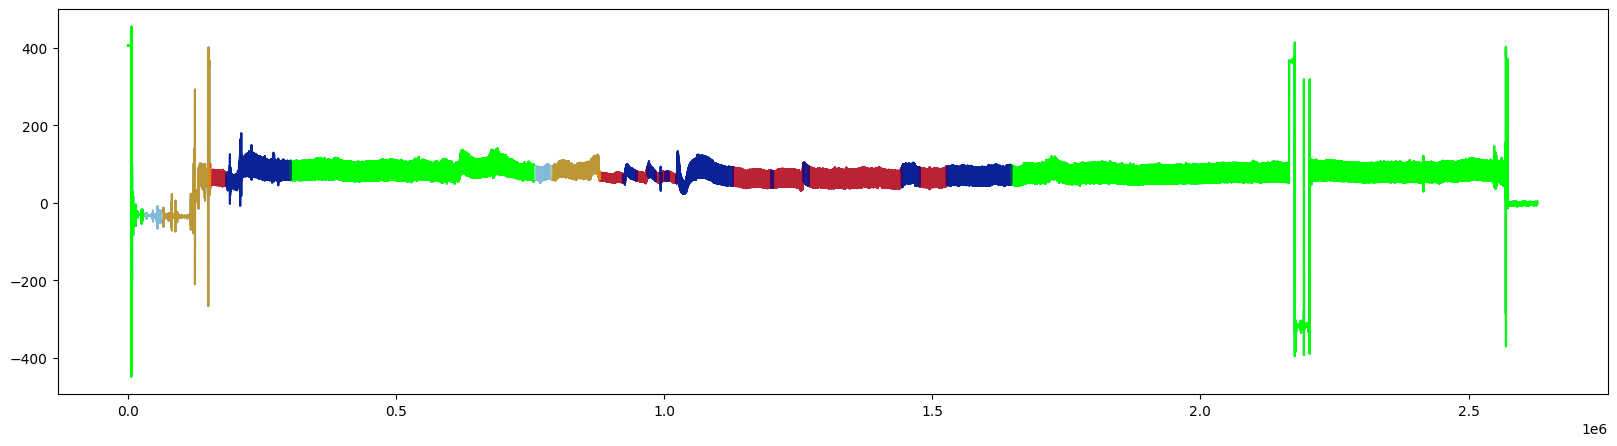

In [9]:
# 겹쳐보이는 지점들은 실제로는 겹치지 않는다. 해상도 문제로 인한 것이다.

plt.figure(figsize=(20, 5))
plt.plot(sig)

for e in neg_events:
    plt.plot(range(*e), sig[range(*e)], color="lime")

for e in actual_pos_events:
    plt.plot(range(*e), sig[range(*e)], color="red", alpha=0.7)

for e in pred_pos_events:
    plt.plot(range(*e), sig[range(*e)], color="orange", alpha=0.7)

for e in soft_gray_zones:
    plt.plot(range(*e), sig[range(*e)], color="lightblue", alpha=0.7)

for e in hard_gray_zones:
    plt.plot(range(*e), sig[range(*e)], color="darkblue", alpha=0.7)
plt.show()

### HypophetVersion2

#### sampling version 0
- pos: 30 second, non-overlapping
- neg: 30 second, 2.5 minute stride

In [10]:
input_len = config["input_len"] * config["fs"]
stride = (
    config["segment"]["seg_stride"] * config["fs"] * config["segment"]["seg_density"]
)

In [44]:
try:
    pos_seg = np.vstack(
        [
            sliding_window_view(np.arange(*e), input_len)[::input_len]
            for e in pred_pos_events
        ]
    )
    pos_segments = np.vstack([(e[0], e[-1] + 1) for e in pos_seg])
except ValueError or IndexError:
    print("No positive segments extracted.")
    pos_segments = np.array([], dtype=np.int32)

In [45]:
try:
    neg_seg = np.vstack(
        [sliding_window_view(np.arange(*e), input_len)[::stride] for e in neg_events]
    )
    neg_segments = np.vstack([(e[0], e[-1] + 1) for e in neg_seg])
except ValueError or IndexError:
    print("No negative segments extracted.")
    neg_segments = np.array([], dtype=np.int32)

In [46]:
pos_segments.shape, neg_segments.shape

((90, 2), (20, 2))

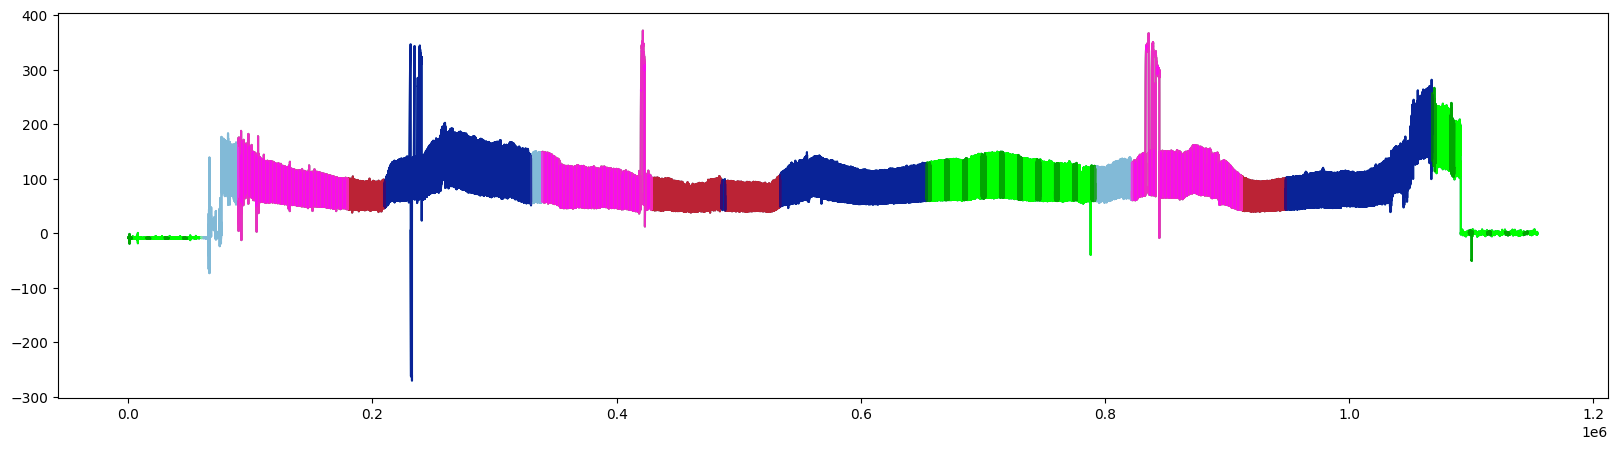

In [48]:
# 겹쳐보이는 지점들은 실제로는 겹치지 않는다. 해상도 문제로 인한 것이다.

plt.figure(figsize=(20, 5))
plt.plot(sig)

for e in neg_events:
    plt.plot(range(*e), sig[range(*e)], color="lime")

for e in actual_pos_events:
    plt.plot(range(*e), sig[range(*e)], color="red", alpha=0.7)

for e in pred_pos_events:
    plt.plot(range(*e), sig[range(*e)], color="orange", alpha=0.7)

for e in soft_gray_zones:
    plt.plot(range(*e), sig[range(*e)], color="lightblue", alpha=0.7)

for e in hard_gray_zones:
    plt.plot(range(*e), sig[range(*e)], color="darkblue", alpha=0.7)

for s in pos_segments:
    plt.plot(range(*s), sig[range(*s)], color="magenta", alpha=0.7)

for s in neg_segments:
    plt.plot(range(*s), sig[range(*s)], color="green", alpha=0.7)
plt.show()

In [10]:
# test
pos_segments = strategy.extract_segment(pred_pos_events, config, "pos")
neg_segments = strategy.extract_segment(neg_events, config, "neg")
print(pos_segments.shape, neg_segments.shape)

(90, 2) (20, 2)


In [11]:
pos_segments = np.load(
    case_path / "6363_100fs_processed_hypophetversion2_adj20_pred_pos_segments.npy"
)
neg_segments = np.load(
    case_path / "6363_100fs_processed_hypophetversion2_adj20_neg_segments.npy"
)

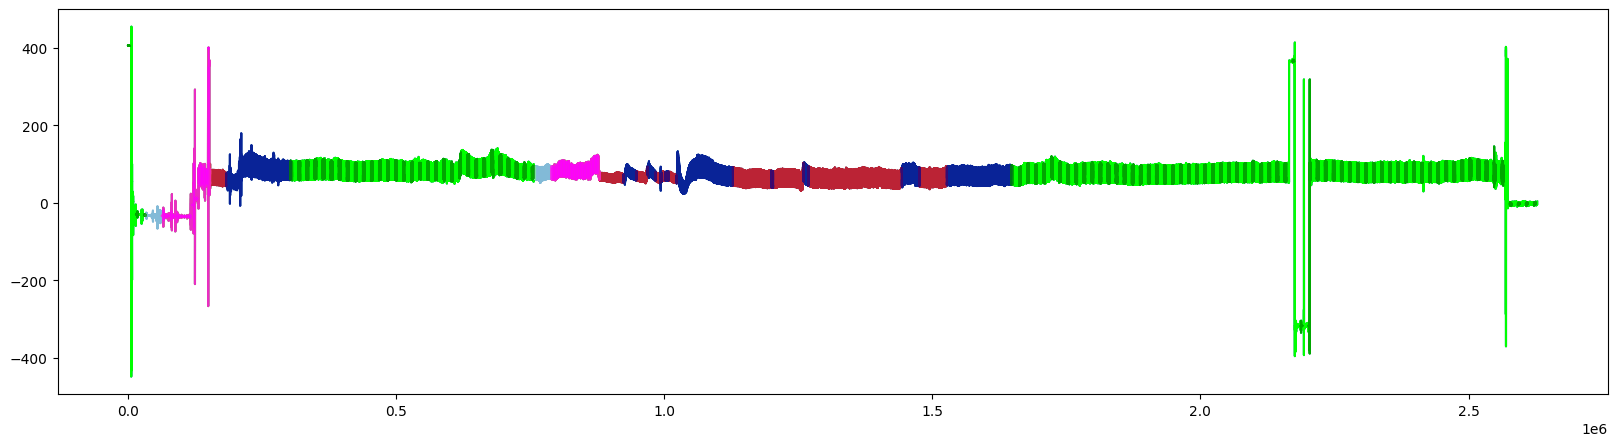

In [12]:
# 겹쳐보이는 지점들은 실제로는 겹치지 않는다. 해상도 문제로 인한 것이다.

plt.figure(figsize=(20, 5))
plt.plot(sig)

for e in neg_events:
    plt.plot(range(*e), sig[range(*e)], color="lime")

for e in actual_pos_events:
    plt.plot(range(*e), sig[range(*e)], color="red", alpha=0.7)

for e in pred_pos_events:
    plt.plot(range(*e), sig[range(*e)], color="orange", alpha=0.7)

for e in soft_gray_zones:
    plt.plot(range(*e), sig[range(*e)], color="lightblue", alpha=0.7)

for e in hard_gray_zones:
    plt.plot(range(*e), sig[range(*e)], color="darkblue", alpha=0.7)

for s in pos_segments:
    plt.plot(range(*s), sig[range(*s)], color="magenta", alpha=0.7)

for s in neg_segments:
    plt.plot(range(*s), sig[range(*s)], color="green", alpha=0.7)
plt.show()

#### sampling version 1
가설: 양성의 수를 늘리면 version 0보다 성능이 더 개선될 것이다.